In [1]:
import abm
import pandas as pd
from plotnine import *

# Set up

In [2]:
model = 'inputs/Models/2compartment_Ab.iqd'
Tpar = pd.read_csv('inputs/Parameters/Parameter_labels.csv')
Vpop = pd.read_csv('inputs/Parameters/Vpop_labels.csv')

# Run model with hand built IQ Analyze parameter table

In [3]:
display(Tpar.sort_values(by = ['ID_lab', 'parameter'], ascending = False))

,ID_lab,parameter,value,unit
7,Mean_BW,Volume_p,13.0,L
4,Mean_BW,Volume_c,3.0,L
10,Mean_BW,Thalf,28.0,d
13,Mean_BW,Receptors_p,10.0,nM
0,Mean_BW,BW,70.0,kg
8,Low_BW,Volume_p,11.0,L
5,Low_BW,Volume_c,2.5,L
11,Low_BW,Thalf,37.0,d
14,Low_BW,Receptors_p,23.0,nM
2,Low_BW,BW,60.0,kg


In [4]:
dose_amt = 10
dose_times = [0,7,14,21]
ID_labs = ['Low_BW','Mean_BW','High_BW']

Tdos = pd.DataFrame({}).assign(dose_amt = [dose_amt], ID_lab = ['*'], route = ['Dose_IV'], times = [dose_times], amounts = [dose_amt],
                               amount_unit = ['mg/kg'], time_unit = ['d'])
Tsim = pd.concat([Tdos[['dose_amt']].assign(ID_lab = x) for x in ID_labs])

In [5]:
display(Tdos)
display(Tsim)

,dose_amt,ID_lab,route,times,amounts,amount_unit,time_unit
0,10,*,Dose_IV,"[0, 7, 14, 21]",10,mg/kg,d


,dose_amt,ID_lab
0,10,Low_BW
0,10,Mean_BW
0,10,High_BW


In [6]:
Tres = abm.simulate(models = model,
                    parameters = Tpar,
                    doses = Tdos,
                    simulations = Tsim,
                    outputs = ['free_drug_c', 'RO_p'],
                    times = abm.linspace(0,35,701,'d')).to_pandas(tall_outputs = True)

Total: 3, Running: 0, Succeeded: 3, Failed: 0

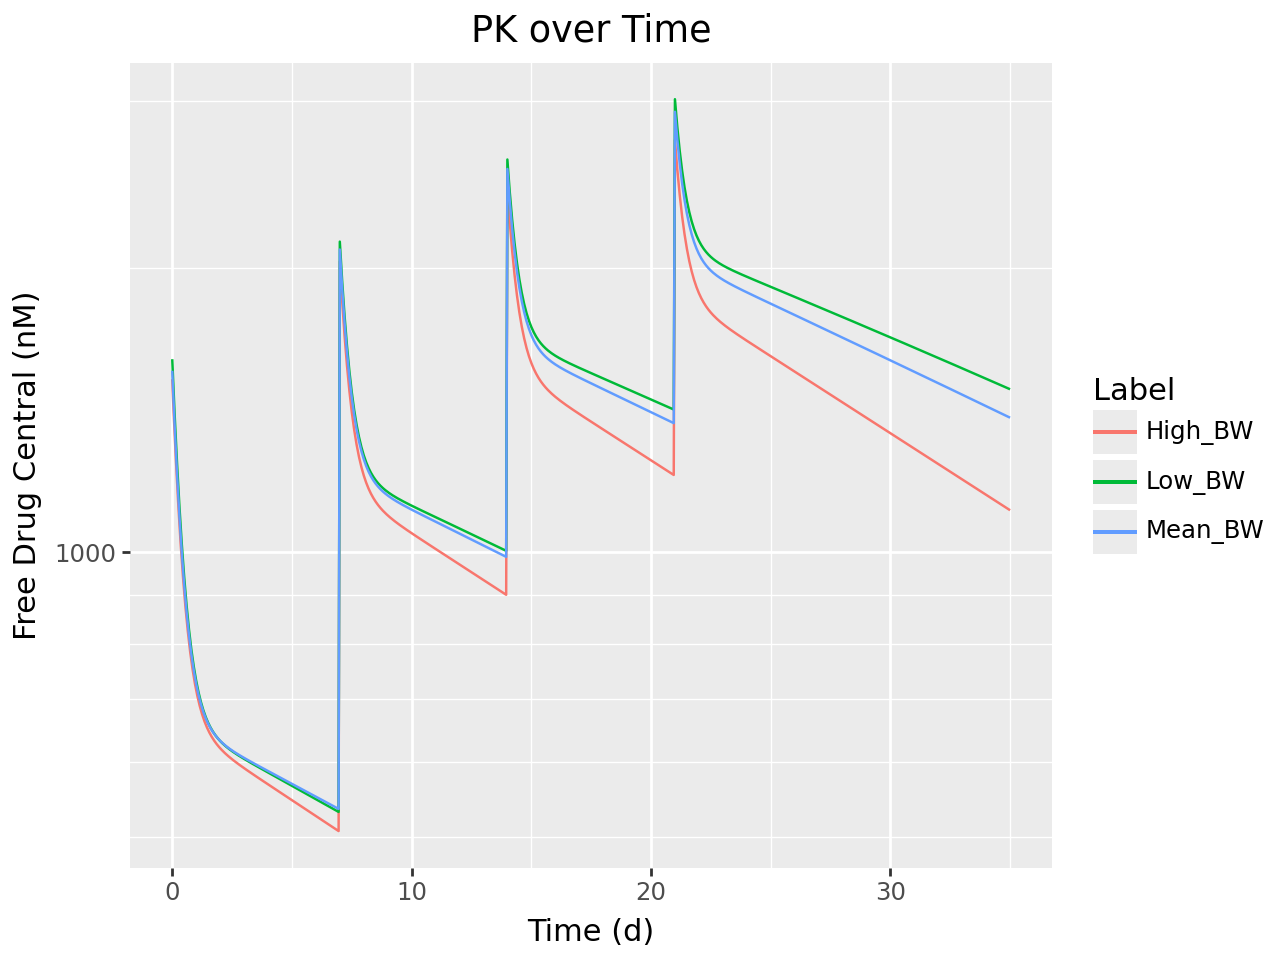

In [7]:
fig_PK = (ggplot()
          + geom_line(data = Tres.query('output == "free_drug_c"'), mapping = aes(x = 't', y = 'value',color = 'factor(ID_lab)'))
          + scale_y_log10(breaks = [0.1,1,10,100,1000])
          + labs(x = 'Time (d)', y = 'Free Drug Central (nM)', color = 'Label', title = 'PK over Time')
         )

display(fig_PK)

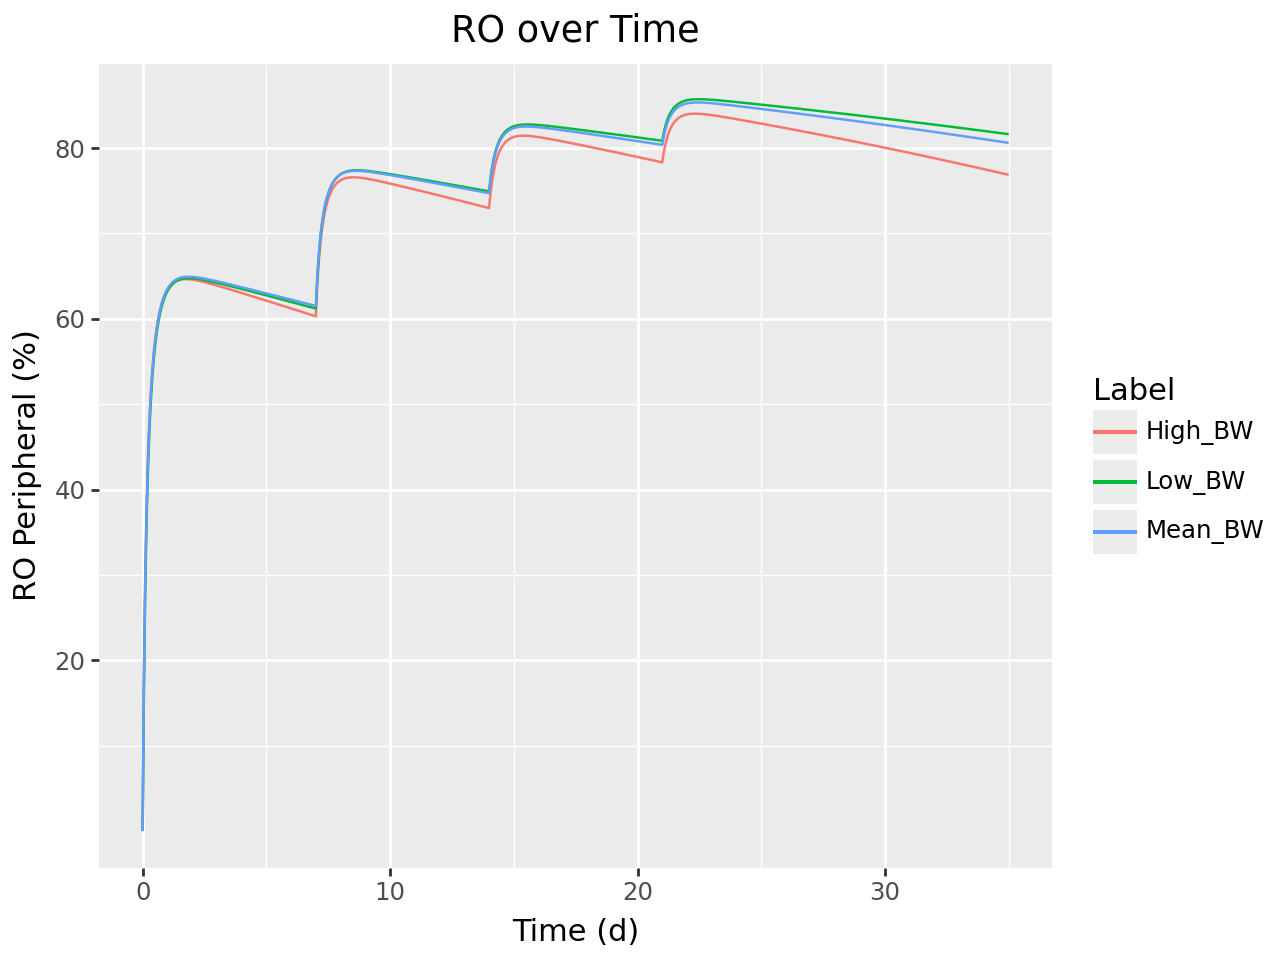

In [8]:
fig_PK = (ggplot()
          + geom_line(data = Tres.query('output == "RO_p"'), mapping = aes(x = 't', y = 'value',color = 'factor(ID_lab)'))
          + scale_y_continuous(breaks = [20,40, 60, 80])
          + labs(x = 'Time (d)', y = 'RO Peripheral (%)', color = 'Label', title = 'RO over Time')
         )

display(fig_PK)

# Converting IQ Design Vpop file into an IQ Analyze Parameter table

In [9]:
display(Vpop)

,ID,BW,Volume_c,Volume_p,Thalf,Receptors_p
0,1,70,3.0,13,28,10
1,2,60,2.5,11,37,23
2,3,80,3.5,15,19,2


In [10]:
ID_dict = {1:'Mean_BW', 2:'Low_BW', 3: 'High_BW'}

In [11]:
Vpop_rename = Vpop.copy()
Vpop_rename['ID'] = Vpop_rename.apply(lambda x: ID_dict[x.ID], axis = 1)

display(Vpop_rename)

,ID,BW,Volume_c,Volume_p,Thalf,Receptors_p
0,Mean_BW,70,3.0,13,28,10
1,Low_BW,60,2.5,11,37,23
2,High_BW,80,3.5,15,19,2


In [12]:
Tpar_infer = Vpop_rename.melt(id_vars = 'ID', var_name = 'parameter', value_name = 'value')

unit_dict = {'BW':'kg', 'Volume_c':'L','Volume_p':'L','Thalf':'d','Receptors_p':'nM'}

Tpar_infer['unit'] = Tpar_infer.apply(lambda x: unit_dict[x.parameter], axis = 1)

Tpar_infer = pd.concat([Tpar_infer, pd.DataFrame({'ID':['*','*'], 'parameter':['Dose_amt_IV', 'Dose_amt_SC'],
                                                  'value':[0,0], 'unit':['mg/kg','mg/kg']})])

In [13]:
display(Tpar_infer)

,ID,parameter,value,unit
0,Mean_BW,BW,70.0,kg
1,Low_BW,BW,60.0,kg
2,High_BW,BW,80.0,kg
3,Mean_BW,Volume_c,3.0,L
4,Low_BW,Volume_c,2.5,L
5,High_BW,Volume_c,3.5,L
6,Mean_BW,Volume_p,13.0,L
7,Low_BW,Volume_p,11.0,L
8,High_BW,Volume_p,15.0,L
9,Mean_BW,Thalf,28.0,d


In [14]:
dose_amt = 10
dose_times = [0,7,14,21,28]

Tdos2 = pd.DataFrame({}).assign(dose_amt = [dose_amt], ID = ['*'], route = ['Dose_IV'], times = [dose_times], amounts = [dose_amt],
                               amount_unit = ['mg/kg'], time_unit = ['d'])

Tsim2 = pd.concat([Tdos2[['dose_amt']].assign(ID = x) for x in Tpar_infer.ID.unique() if x != '*'])

In [15]:
display(Tdos2)
display(Tsim2)

,dose_amt,ID,route,times,amounts,amount_unit,time_unit
0,10,*,Dose_IV,"[0, 7, 14, 21, 28]",10,mg/kg,d


,dose_amt,ID
0,10,Mean_BW
0,10,Low_BW
0,10,High_BW


In [16]:
Tres2 = abm.simulate(models = model,
                    parameters = Tpar_infer,
                    doses = Tdos2,
                    simulations = Tsim2,
                    outputs = ['free_drug_c', 'RO_p'],
                    times = abm.linspace(0,35,701,'d')).to_pandas(tall_outputs = True)

Total: 0, Running: 0, Succeeded: 0, Failed: 0

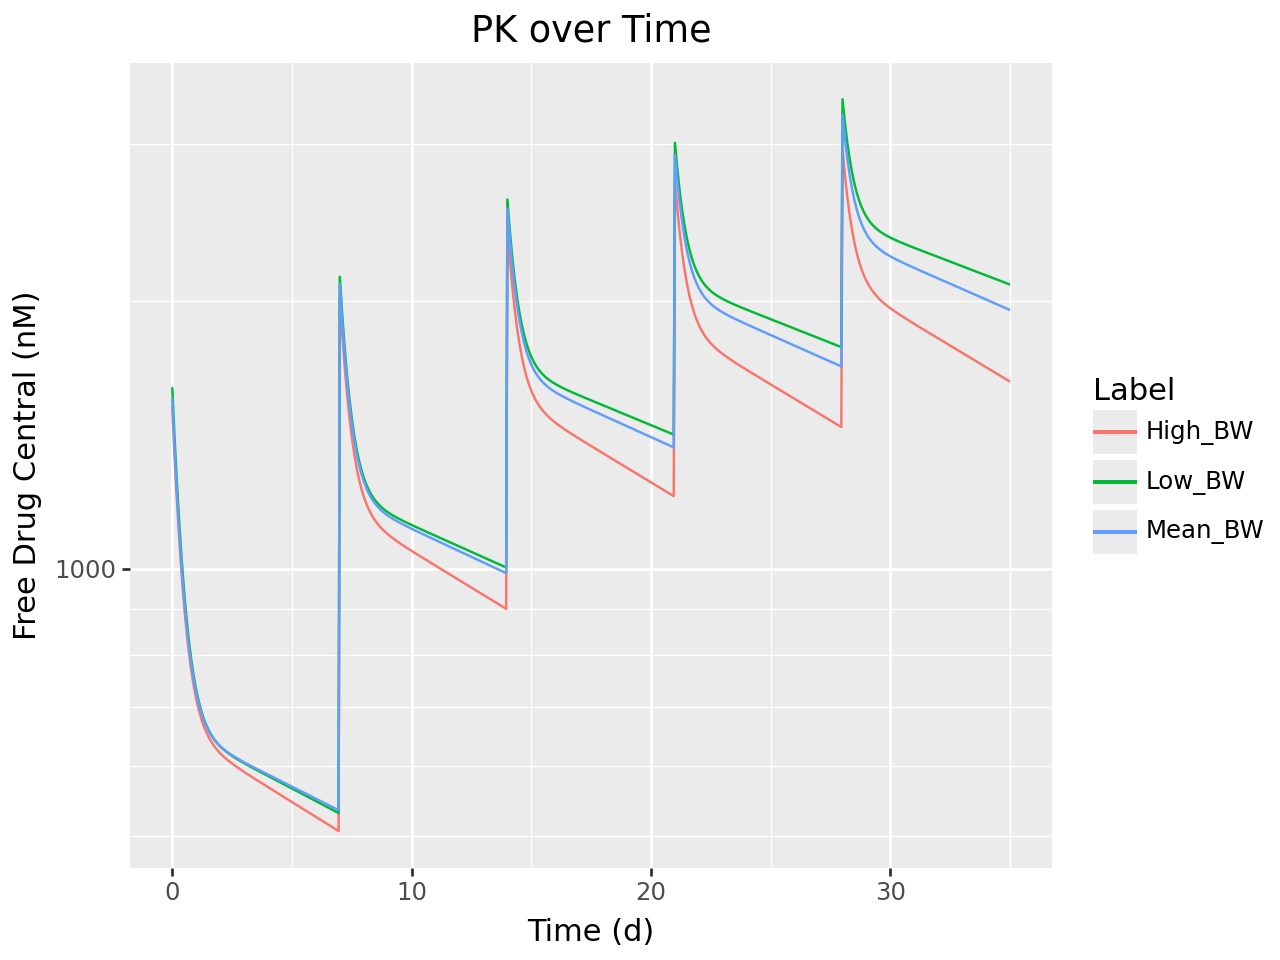

In [17]:
fig_PK = (ggplot()
          + geom_line(data = Tres2.query('output == "free_drug_c"'), mapping = aes(x = 't', y = 'value',color = 'factor(ID)'))
          + scale_y_log10(breaks = [0.1,1,10,100,1000])
          + labs(x = 'Time (d)', y = 'Free Drug Central (nM)', color = 'Label', title = 'PK over Time')
         )

display(fig_PK)

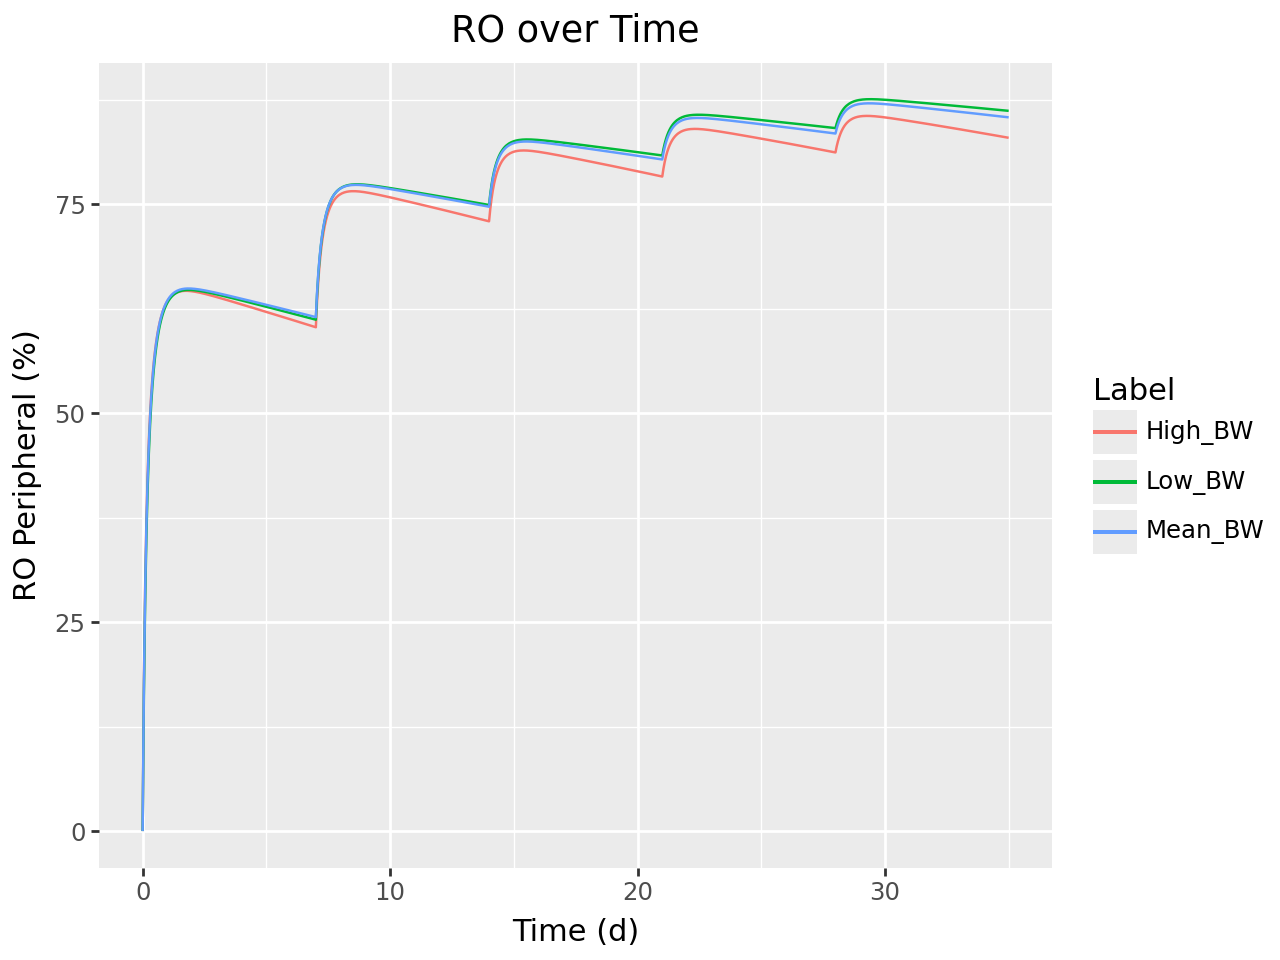

In [18]:
fig_PK = (ggplot()
          + geom_line(data = Tres2.query('output == "RO_p"'), mapping = aes(x = 't', y = 'value',color = 'factor(ID)'))
          + labs(x = 'Time (d)', y = 'RO Peripheral (%)', color = 'Label', title = 'RO over Time')
         )

display(fig_PK)